<a id='table_of_contents'></a>

0. [Import libraries](#imports)
1. [Import data](#import_data)
2. [Data exploration](#data_exploration)
3. [Data cleaning](#data_cleaning)
4. [Data preparation](#data_preparation)
5. [Benchmark model](#benchmark_model)<br>
6. [Feature engineering](#feature_engineering)
7. [Model training](#model_training)<br>
    7.1. [Decision Tree](#decision_tree)<br>
    7.2. [Random Forest](#random_forest)<br>
    7.3. [Comparing algorithm performances](#comparing_algorithm_performances)
8. [Tuning](#tuning)<br>

# 0. Import libraries <a id='imports'></a>
[Back to top](#table_of_contents)

In [2]:
import pandas as pd
import numpy as np


%matplotlib inline

# 1. Import data <a id='import_data'></a>
[Back to top](#table_of_contents)

In [3]:
taxi_jan_2024 = pd.read_parquet('data/yellow_tripdata_2024-01.parquet')
taxi_data = pd.concat([taxi_jan_2024])

In [4]:
print(taxi_data.shape)
taxi_data.head()

(2964624, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


# 2. Data exploration <a id='data_exploration'></a>
[Back to top](#table_of_contents)

In [5]:
taxi_data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='object')

In [6]:
taxi_data = taxi_data[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'total_amount']]

In [7]:
taxi_data.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,186,79,2,22.70
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,140,236,1,18.75
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,236,79,1,31.30
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,79,211,1,17.00
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,211,148,1,16.10


array([[<Axes: title={'center': 'tpep_pickup_datetime'}>,
        <Axes: title={'center': 'tpep_dropoff_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>],
       [<Axes: title={'center': 'trip_distance'}>,
        <Axes: title={'center': 'RatecodeID'}>,
        <Axes: title={'center': 'PULocationID'}>],
       [<Axes: title={'center': 'DOLocationID'}>,
        <Axes: title={'center': 'payment_type'}>,
        <Axes: title={'center': 'total_amount'}>]], dtype=object)

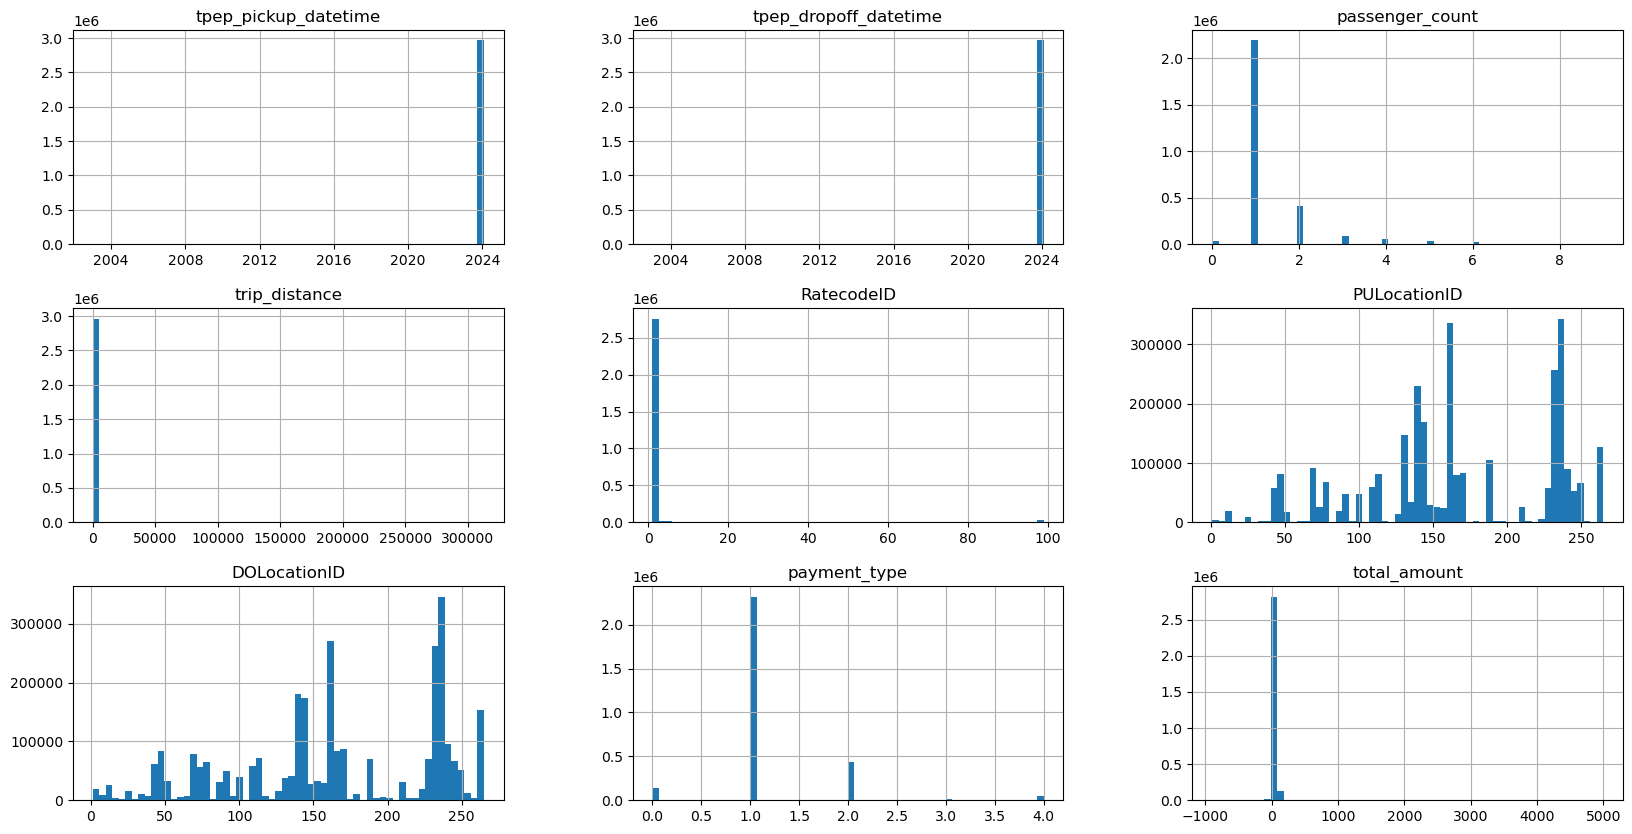

In [8]:
taxi_data.hist(figsize=(20, 10), bins=60)

In [9]:
taxi_data['RatecodeID'].value_counts()

RatecodeID
1.0     2663350
2.0       98713
99.0      28663
5.0       19410
3.0        7954
4.0        6365
6.0           7
Name: count, dtype: int64

<Axes: xlabel='index', ylabel='total_amount'>

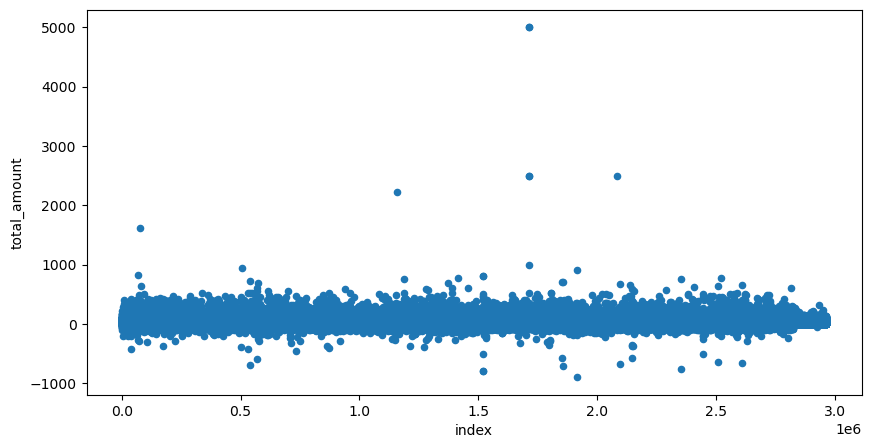

In [10]:
taxi_data.reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10, 5))

In [11]:
# import seaborn as sns
# sns.relplot(
#   data=taxi_data.reset_index(),
#   kind='scatter',
#   y='total_amount',
#   x='index',
#   hue='payment_type',
#   height=5,
#   aspect=2
# )

<Axes: xlabel='index', ylabel='total_amount'>

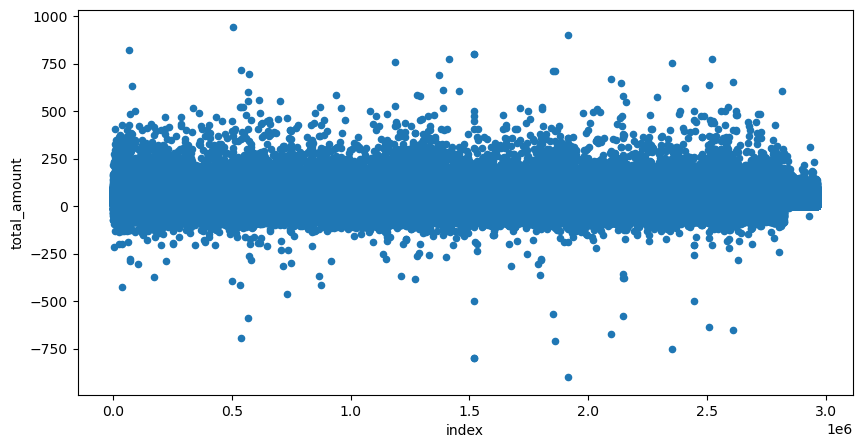

In [12]:
taxi_data[taxi_data['total_amount'] < 1000].reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10, 5))

Two things to deal with: negative values and high values. Let's first look at negative values.

(35504, 9)


<Axes: xlabel='index', ylabel='total_amount'>

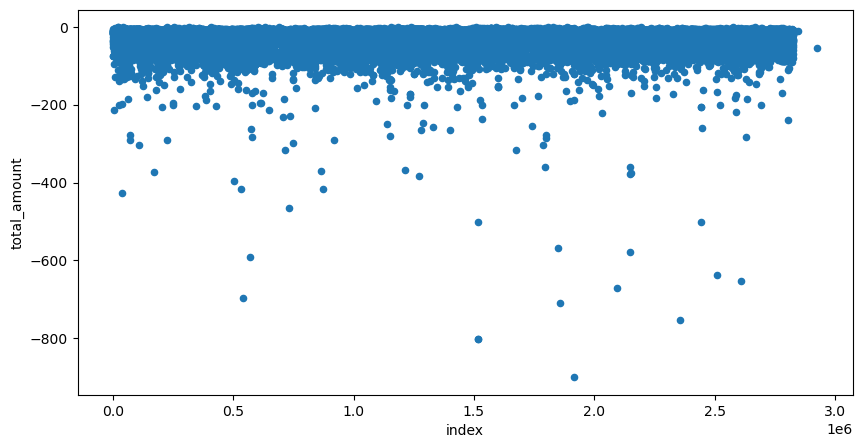

In [13]:
print(taxi_data[taxi_data['total_amount'] < 0].shape)
taxi_data[taxi_data['total_amount'] < 0].reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10, 5))

In [14]:
taxi_data[taxi_data['total_amount'] < 0].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
99,2024-01-01 00:18:24,2024-01-01 00:30:39,1.0,2.16,1.0,249,232,4,-18.50
506,2024-01-01 00:04:00,2024-01-01 00:04:44,1.0,0.01,5.0,63,63,2,-34.25
536,2024-01-01 00:41:42,2024-01-01 00:46:00,1.0,0.47,1.0,249,113,4,-10.80
552,2024-01-01 00:42:02,2024-01-01 01:14:33,1.0,5.48,1.0,107,61,2,-38.10
682,2024-01-01 00:24:02,2024-01-01 01:10:32,1.0,8.74,1.0,90,225,4,-52.80


In [15]:
taxi_data[taxi_data['total_amount'] < 0]['payment_type'].value_counts()

payment_type
4    21406
2     8326
3     5741
1       29
0        2
Name: count, dtype: int64

<Axes: >

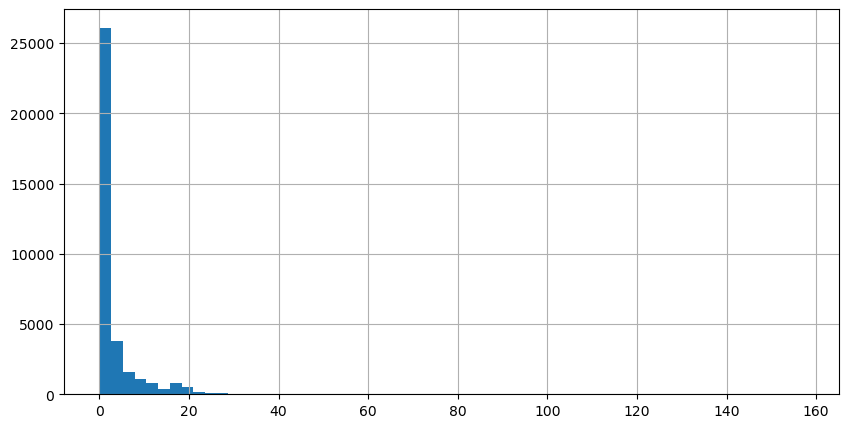

In [16]:
taxi_data[taxi_data['total_amount'] < 0]['trip_distance'].hist(bins=60, figsize=(10, 5))

In [17]:
print(taxi_data[taxi_data['total_amount'] == 0].shape)
taxi_data[taxi_data['total_amount'] == 0].head()

(416, 9)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
854,2024-01-01 00:27:42,2024-01-01 00:28:49,1.0,0.2,1.0,239,143,4,0.0
29224,2024-01-01 10:01:27,2024-01-01 10:01:27,1.0,0.0,5.0,239,264,2,0.0
39191,2024-01-01 13:46:41,2024-01-01 14:12:06,1.0,0.0,99.0,42,216,1,0.0
39591,2024-01-01 13:03:22,2024-01-01 13:03:24,1.0,0.0,1.0,264,264,2,0.0
39592,2024-01-01 13:05:28,2024-01-01 13:05:35,1.0,0.0,1.0,193,193,2,0.0


In [18]:
taxi_data[taxi_data['total_amount'] == 0]['payment_type'].value_counts()

payment_type
1    129
4    128
3     83
2     65
0     11
Name: count, dtype: int64

<Axes: >

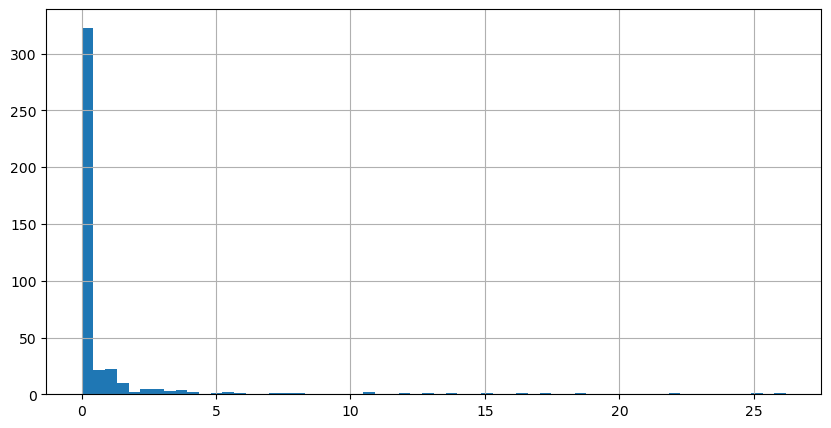

In [19]:
taxi_data[taxi_data['total_amount'] == 0]['trip_distance'].hist(bins=60, figsize=(10, 5))

In [20]:
taxi_data[taxi_data['total_amount'] == 0]['trip_distance'].value_counts()

trip_distance
0.00     287
0.10      21
0.20       8
0.90       8
0.50       7
1.60       6
0.80       5
0.70       5
1.00       5
0.60       4
1.30       4
0.30       4
1.10       4
3.00       3
2.50       3
0.40       3
3.40       2
3.80       2
1.70       2
10.70      2
1.80       2
2.40       2
1.20       1
5.50       1
8.10       1
2.70       1
3.60       1
5.80       1
13.60      1
26.20      1
3.50       1
7.70       1
4.90       1
21.90      1
16.50      1
5.30       1
4.00       1
25.10      1
1.40       1
12.80      1
4.20       1
1.74       1
12.10      1
15.00      1
18.40      1
3.30       1
2.90       1
17.10      1
7.00       1
Name: count, dtype: int64

We can safely get rid of the negative values. What about the very high values ?

<Axes: xlabel='index', ylabel='total_amount'>

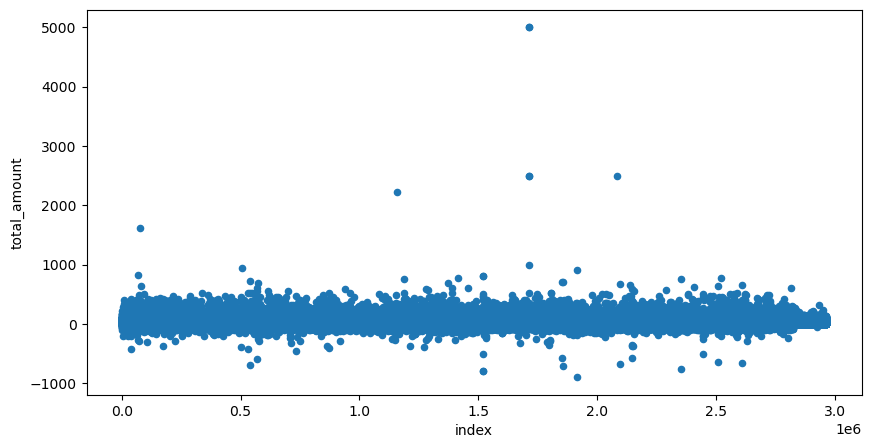

In [21]:
taxi_data.reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10, 5))

In [22]:
taxi_data[taxi_data['total_amount'] > 200].shape

(2005, 9)

In [23]:
taxi_data.shape

(2964624, 9)

In [24]:
taxi_data[(taxi_data['total_amount'] < 200) & (taxi_data['total_amount'] < 0)].shape

(35504, 9)

In [25]:
taxi_data['total_amount'].mean()

np.float64(26.801504770925415)

We can agree to cut from $200 level.

# 3. Data cleaning <a id='data_cleaning'></a>
[Back to top](#table_of_contents)

In [26]:
taxi_data_filtered = taxi_data[(taxi_data['total_amount'] >= 0) & (taxi_data['total_amount'] <= 200)]

In [27]:
print(taxi_data.shape)
taxi_data_filtered.shape

(2964624, 9)


(2927115, 9)

In [28]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          140153
trip_distance                 0
RatecodeID               140153
PULocationID                  0
DOLocationID                  0
payment_type                  0
total_amount                  0
dtype: int64

# 4. Data preparation <a id='data_preparation'></a>
[Back to top](#table_of_contents)

In [29]:
taxi_data_prepared = taxi_data_filtered.copy()

Making sure everything is in the right type.

In [30]:
taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
total_amount                    float64
dtype: object

In [31]:
# taxi_data_prepared.loc[:, 'tpep_pickup_datetime'] = pd.to_datetime(taxi_data_prepared.loc[:, 'tpep_pickup_datetime'])
# taxi_data_prepared.loc[:, 'tpep_dropoff_datetime'] = pd.to_datetime(taxi_data_prepared.loc[:, 'tpep_dropoff_datetime'])

In [32]:
taxi_data_prepared.loc[:, 'RatecodeID'] = taxi_data_prepared['RatecodeID'].astype('category')
taxi_data_prepared.loc[:, 'PULocationID'] = taxi_data_prepared['PULocationID'].astype('category')
taxi_data_prepared.loc[:, 'DOLocationID'] = taxi_data_prepared['DOLocationID'].astype('category')
taxi_data_prepared.loc[:, 'payment_type'] = taxi_data_prepared['payment_type'].astype('category')

/tmp/ipykernel_108411/2596364470.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.0, 1.0, 1.0, 1.0, 1.0, ..., NaN, NaN, NaN, NaN, NaN]
Length: 2927115
Categories (7, float64): [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 99.0]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  taxi_data_prepared.loc[:, 'RatecodeID'] = taxi_data_prepared['RatecodeID'].astype('category')


In [33]:
taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                     category
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
total_amount                    float64
dtype: object

Transforming variables into the formats we need them

In [34]:
taxi_data_prepared['transaction_date'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime'].dt.date)
# -> we make it datetime again because it's very little use when it's just a string (can't compare, sort, etc.)
taxi_data_prepared['transaction_year'] = taxi_data_prepared['tpep_pickup_datetime'].dt.year
taxi_data_prepared['transaction_month'] = taxi_data_prepared['tpep_pickup_datetime'].dt.month
taxi_data_prepared['transaction_day'] = taxi_data_prepared['tpep_pickup_datetime'].dt.day
taxi_data_prepared['transaction_hour'] = taxi_data_prepared['tpep_pickup_datetime'].dt.hour

In [35]:
taxi_data_prepared.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,transaction_date,transaction_year,transaction_month,transaction_day,transaction_hour
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,186,79,2,22.70,2024-01-01,2024,1,1,0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,140,236,1,18.75,2024-01-01,2024,1,1,0
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,236,79,1,31.30,2024-01-01,2024,1,1,0
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,79,211,1,17.00,2024-01-01,2024,1,1,0
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,211,148,1,16.10,2024-01-01,2024,1,1,0


array([[<Axes: title={'center': 'tpep_pickup_datetime'}>,
        <Axes: title={'center': 'tpep_dropoff_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>,
        <Axes: title={'center': 'trip_distance'}>],
       [<Axes: title={'center': 'PULocationID'}>,
        <Axes: title={'center': 'DOLocationID'}>,
        <Axes: title={'center': 'payment_type'}>,
        <Axes: title={'center': 'total_amount'}>],
       [<Axes: title={'center': 'transaction_date'}>,
        <Axes: title={'center': 'transaction_year'}>,
        <Axes: title={'center': 'transaction_month'}>,
        <Axes: title={'center': 'transaction_day'}>],
       [<Axes: title={'center': 'transaction_hour'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

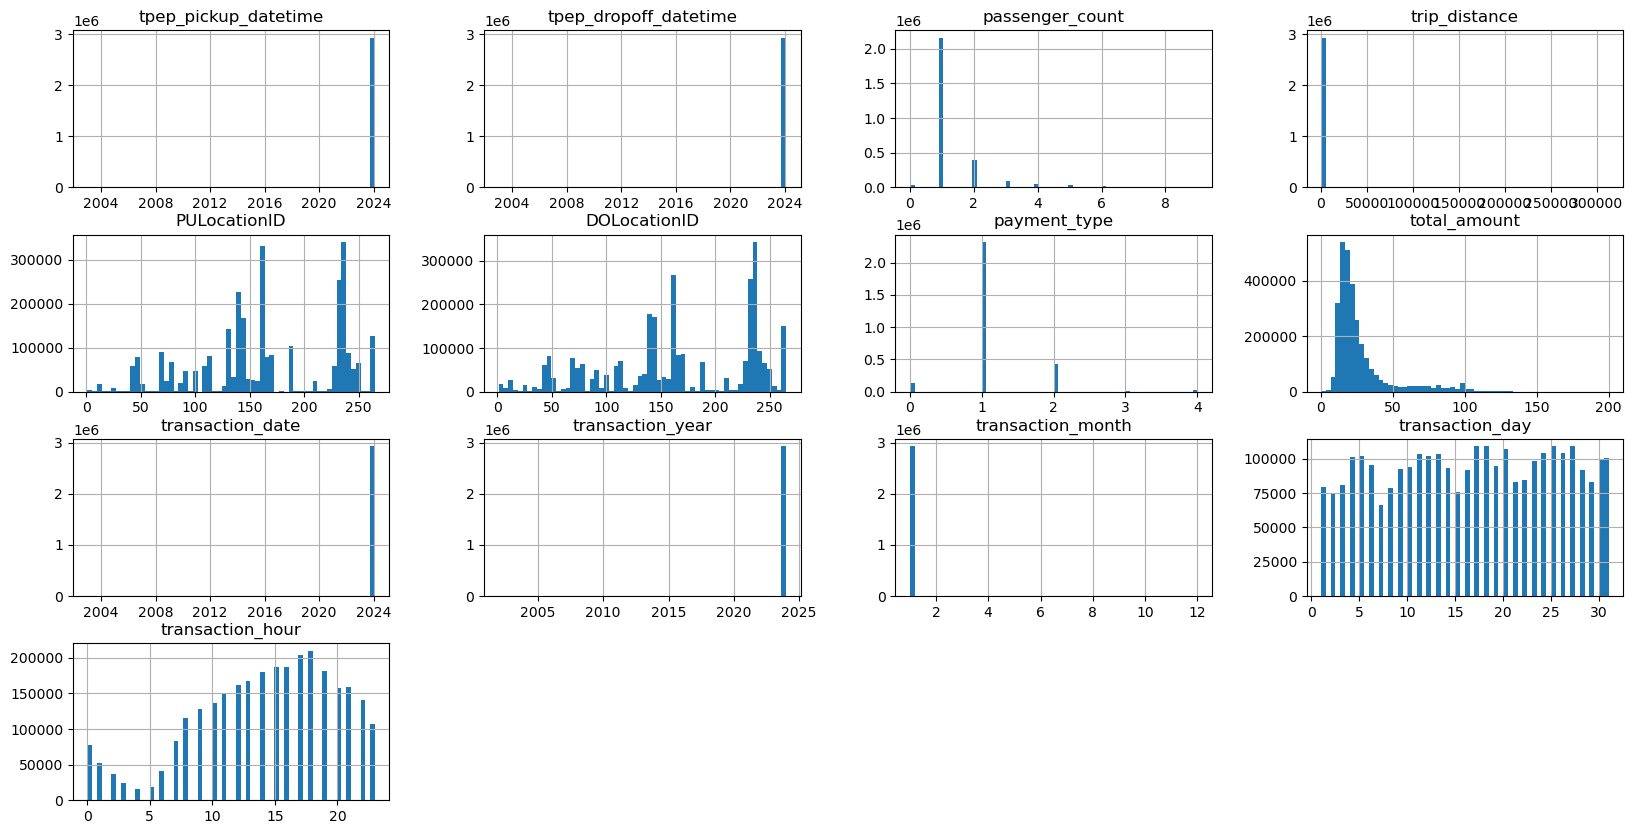

In [36]:
taxi_data_prepared.hist(figsize=(20, 10), bins=60)

In [37]:
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_year'] == 2024]
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_month'] == 1]

Nothing down categorical and numerical columns

In [38]:
categorical_columns = ['PULocationID', 'transaction_date', 'transaction_month', 'transaction_day', 'transaction_hour']
numerical_columns = ['trip_distance', 'total_amount']
all_needed_columns = categorical_columns + numerical_columns

In [39]:
main_taxi_df = taxi_data_prepared[all_needed_columns]
print(main_taxi_df.shape)
main_taxi_df.head()

(2927098, 7)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount
0,186,2024-01-01,1,1,0,1.72,22.70
1,140,2024-01-01,1,1,0,1.80,18.75
2,236,2024-01-01,1,1,0,4.70,31.30
3,79,2024-01-01,1,1,0,1.40,17.00
4,211,2024-01-01,1,1,0,0.80,16.10


Aggregate data points\
Now is a good time to think about what we want to predict. Depending on this, we need to transform our data to have a certain format.

In [40]:
taxi_grouped_by_region = main_taxi_df.groupby(categorical_columns).mean().reset_index()
taxi_grouped_by_region['count_of_transactions'] = main_taxi_df.groupby(categorical_columns).count().reset_index()['total_amount']
print(taxi_grouped_by_region.shape)
taxi_grouped_by_region.head()

(77433, 8)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2024-01-01,1,1,5,0.000000,109.200000,1
1,1,2024-01-01,1,1,6,0.020000,76.000000,3
2,1,2024-01-01,1,1,13,0.000000,108.983333,3
3,1,2024-01-01,1,1,14,0.001667,85.680000,6
4,1,2024-01-01,1,1,15,0.000000,145.620000,2


<Axes: >

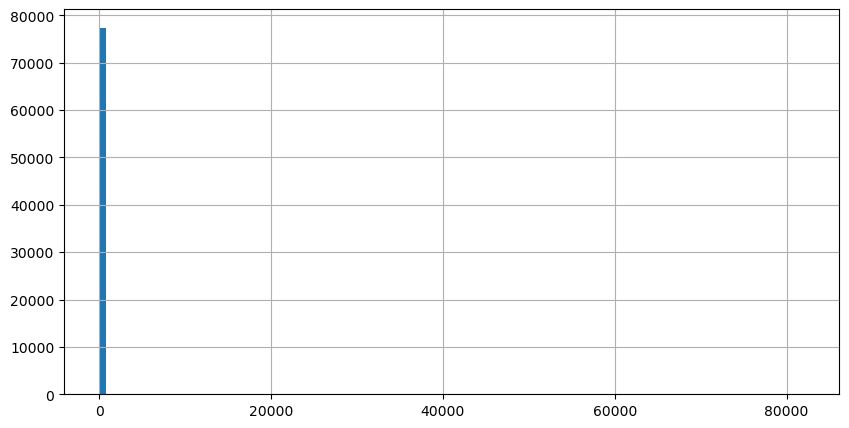

In [41]:
taxi_grouped_by_region['trip_distance'].hist(bins=100, figsize=(10, 5))

<Axes: >

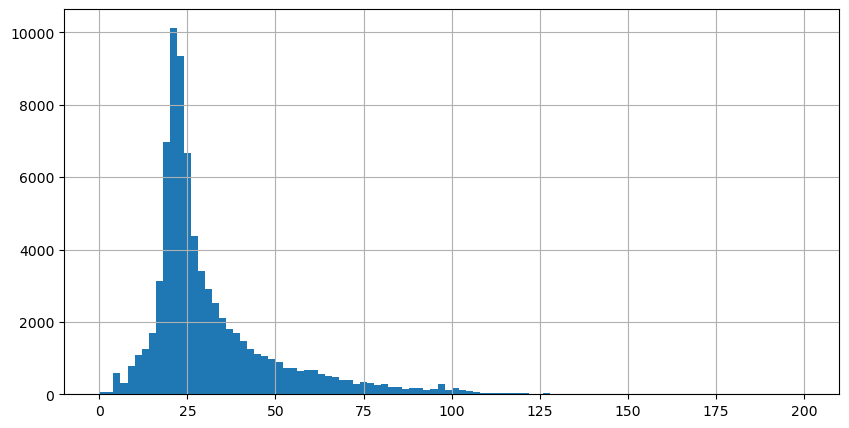

In [42]:
taxi_grouped_by_region['total_amount'].hist(bins=100, figsize=(10, 5))

# 5. Benchmark model <a id='benchmark_model'></a>
[Back to top](#table_of_contents)

In [43]:
data_for_benchmark_model = taxi_grouped_by_region.copy()

In [44]:
categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour']
input_features_benchmark = categorical_features_benchmark + ['trip_distance']
target_features_benchmark = 'total_amount'

## 5.1. Train-test split <a id='train_test_split'></a>

In [45]:
from sklearn.model_selection import train_test_split

X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_features_benchmark]

# one-hot encode
X_bench = pd.get_dummies(X_bench)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)

## 5.2. Fit a model to the data <a id='fit_a_model_to_the_data'></a>

In [46]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train_b, y_train_b)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## 5.3. Model evalutation <a id='model_evaluation'></a>

In [47]:
model_at_hand = tree

y_pred_b = model_at_hand.predict(X_test_b)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt


print('mean_absolute_error', mean_absolute_error(y_test_b, y_pred_b))
print('mean_squared_error', mean_squared_error(y_test_b, y_pred_b))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test_b, y_pred_b)))
print('r2', r2_score(y_test_b, y_pred_b))

mean_absolute_error 6.630767769783662
mean_squared_error 167.87110615463257
root_mean_squared_error 12.956508254720196
r2 0.562793013849046


<Axes: xlabel='true', ylabel='pred'>

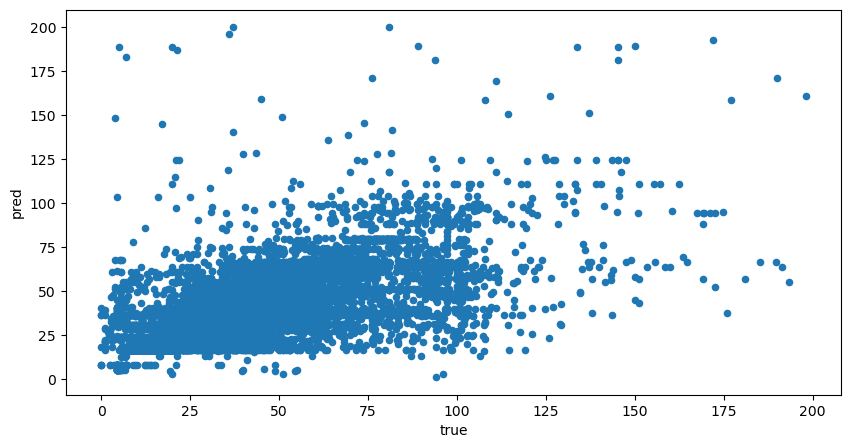

In [48]:
data = {'true': y_test_b, 'pred': y_pred_b}
results = pd.DataFrame(data)


results.plot(figsize=(10, 5), kind='scatter', x='true', y='pred')

Could this be too good to be true?

## 5.4. Fix problems <a id='fix_problems'></a>

In [49]:
categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour']
input_features_benchmark = categorical_features_benchmark
target_features_benchmark = 'total_amount'

# Train and test split
from sklearn.model_selection import train_test_split

X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_features_benchmark]

# one-hot encode
X_bench = pd.get_dummies(X_bench)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)

# Fit a model
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train_b, y_train_b)

# Evaluate model
model_at_hand = tree

y_pred_b = model_at_hand.predict(X_test_b)


from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt


print('mean_absolute_error', mean_absolute_error(y_test_b, y_pred_b))
print('mean_squared_error', mean_squared_error(y_test_b, y_pred_b))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test_b, y_pred_b)))
print('r2', r2_score(y_test_b, y_pred_b))

mean_absolute_error 9.912819305962895
mean_squared_error 259.5936036134993
root_mean_squared_error 16.11190875140184
r2 0.32390904152750555


<Axes: xlabel='true', ylabel='pred'>

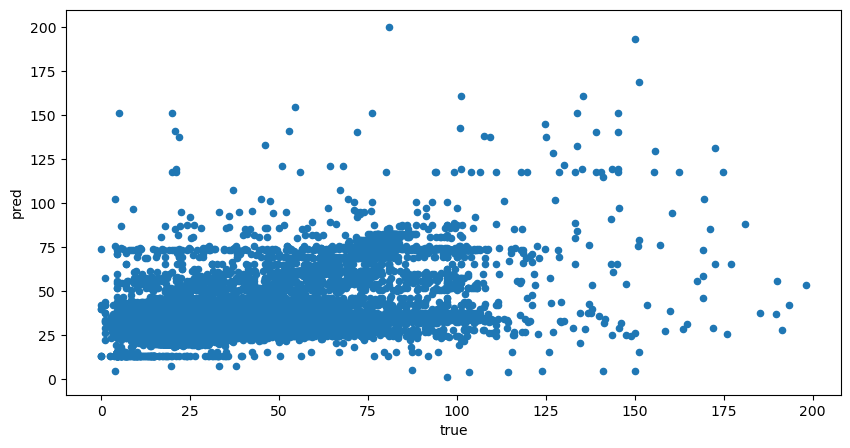

In [50]:
data = {'true': y_test_b, 'pred': y_pred_b}
results = pd.DataFrame(data)


results.plot(figsize=(10, 5), kind='scatter', x='true', y='pred')

# 6. Feature engineering <a id='feature_engineering'></a>
[Back to top](#table_of_contents)

In [51]:
taxi_grouped_by_region.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2024-01-01,1,1,5,0.000000,109.200000,1
1,1,2024-01-01,1,1,6,0.020000,76.000000,3
2,1,2024-01-01,1,1,13,0.000000,108.983333,3
3,1,2024-01-01,1,1,14,0.001667,85.680000,6
4,1,2024-01-01,1,1,15,0.000000,145.620000,2


In [52]:
data_with_new_features = taxi_grouped_by_region.copy()

Date-related features

In [53]:
data_with_new_features['transaction_week_day'] = data_with_new_features['transaction_date'].dt.weekday
data_with_new_features['weekend'] = data_with_new_features['transaction_week_day'].apply(lambda x: True if x == 5 or x == 6 else False)

In [54]:
from pandas.tseries.holiday import USFederalHolidayCalendar

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2023', end='2025').date
data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].isin(holidays)

/tmp/ipykernel_108411/708454413.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].isin(holidays)


In [55]:
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday
0,1,2024-01-01,1,1,5,0.000000,109.200000,1,0,False,True
1,1,2024-01-01,1,1,6,0.020000,76.000000,3,0,False,True
2,1,2024-01-01,1,1,13,0.000000,108.983333,3,0,False,True
3,1,2024-01-01,1,1,14,0.001667,85.680000,6,0,False,True
4,1,2024-01-01,1,1,15,0.000000,145.620000,2,0,False,True


Borough information

In [56]:
zone_lookup = pd.read_csv('data/taxi_zone_lookup.csv')
zone_lookup = zone_lookup[['LocationID', 'Borough']]
zone_lookup['LocationID'] = zone_lookup['LocationID'].astype('category')
zone_lookup.head()

,LocationID,Borough
0,1,EWR
1,2,Queens
2,3,Bronx
3,4,Manhattan
4,5,Staten Island


In [57]:
data_with_new_features = data_with_new_features.merge(zone_lookup, left_on='PULocationID', right_on='LocationID', how='left')
data_with_new_features.drop('LocationID', axis=1, inplace=True)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2024-01-01,1,1,5,0.000000,109.200000,1,0,False,True,EWR
1,1,2024-01-01,1,1,6,0.020000,76.000000,3,0,False,True,EWR
2,1,2024-01-01,1,1,13,0.000000,108.983333,3,0,False,True,EWR
3,1,2024-01-01,1,1,14,0.001667,85.680000,6,0,False,True,EWR
4,1,2024-01-01,1,1,15,0.000000,145.620000,2,0,False,True,EWR


In [58]:
data_with_new_features['Borough'].value_counts()

Borough
Manhattan        42075
Queens           14978
Brooklyn         13558
Bronx             5283
Unknown            722
EWR                181
Staten Island       68
Name: count, dtype: int64

Weather related features

In [59]:
nyc_weather = pd.read_csv('data/nyc_weather.csv')
nyc_weather.head()

,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation
0,31.12.2019 22:00,6.1,65,6,100%.,0.3
1,31.12.2019 19:00,6.7,71,5,70 – 80%.,NaN
2,31.12.2019 16:00,7.2,66,5,50%.,NaN
3,31.12.2019 13:00,6.1,76,3,100%.,Trace of precipitation
4,31.12.2019 10:00,4.4,83,2,100%.,Trace of precipitation


In [60]:
nyc_weather.shape

(2936, 6)

There are some missing values and there are percentage values that we cannot work easily with. Let's look at them more closely.

In [61]:
nyc_weather.dtypes

date and time               object
temperature                float64
humidity                     int64
wind speed                   int64
cloud cover                 object
amount of precipitation     object
dtype: object

In [62]:
nyc_weather['cloud cover'].value_counts()

cloud cover
70 – 80%.                                                     973
100%.                                                         896
20–30%.                                                       479
50%.                                                          413
no clouds                                                     168
Sky obscured by fog and/or other meteorological phenomena.      3
Name: count, dtype: int64

In [63]:
nyc_weather['amount of precipitation'].value_counts()

amount of precipitation
Trace of precipitation    266
0.3                        61
2.0                        49
1.0                        45
0.8                        42
0.5                        42
4.0                        33
5.0                        24
3.0                        23
6.0                        19
8.0                        13
7.0                        13
9.0                        11
10.0                       10
12.0                        7
13.0                        7
15.0                        6
11.0                        5
16.0                        3
14.0                        2
22.0                        2
29.0                        2
17.0                        1
18.0                        1
24.0                        1
30.0                        1
35.0                        1
34.0                        1
20.0                        1
68.0                        1
63.0                        1
21.0                        1
25.0            

In [64]:
nyc_weather.isna().sum()

date and time                 0
temperature                   0
humidity                      0
wind speed                    0
cloud cover                   4
amount of precipitation    2240
dtype: int64

In [65]:
nyc_weather['amount of precipitation'] = nyc_weather['amount of precipitation'].replace('Trace of precipitation', 0.1)
nyc_weather['amount of precipitation'] = nyc_weather['amount of precipitation'].astype('float')

# option 1
# nyc_weather['amount of precipitation'].fillna(0, inplace=True)
# option 2
# nyc_weather['amount of precipitation'].fillna(method='ffill', inplace=True)
# option 3
nyc_weather['amount of precipitation'].interpolate(inplace=True)

/tmp/ipykernel_108411/732682625.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nyc_weather['amount of precipitation'].interpolate(inplace=True)


In [66]:
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('70 – 80%.', 0.7)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('100%.', 1)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('20–30%.', 0.3)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('50%.', 0.5)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('no clouds', 0)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('Sky obscured by fog and/or other meteorological phenomena.', 1)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].astype(float)
nyc_weather['cloud cover'].interpolate(inplace=True)


/tmp/ipykernel_108411/276434456.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('Sky obscured by fog and/or other meteorological phenomena.', 1)
/tmp/ipykernel_108411/276434456.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nyc

In [67]:
nyc_weather.dtypes

date and time               object
temperature                float64
humidity                     int64
wind speed                   int64
cloud cover                float64
amount of precipitation    float64
dtype: object

In [68]:
nyc_weather.dtypes

date and time               object
temperature                float64
humidity                     int64
wind speed                   int64
cloud cover                float64
amount of precipitation    float64
dtype: object

In [69]:
# nyc_weather.loc[:, 'date and time'] = pd.to_datetime(nyc_weather.loc[:, 'date and time'])
nyc_weather['date and time'] = pd.to_datetime(nyc_weather['date and time'])

nyc_weather['hour'] = nyc_weather['date and time'].dt.hour
nyc_weather['month'] = nyc_weather['date and time'].dt.month
nyc_weather['day'] = nyc_weather['date and time'].dt.day

/tmp/ipykernel_108411/1872140679.py:2: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  nyc_weather['date and time'] = pd.to_datetime(nyc_weather['date and time'])


In [70]:
nyc_weather.head()

,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation,hour,month,day
0,2019-12-31 22:00:00,6.1,65,6,1.0,0.300000,22,12,31
1,2019-12-31 19:00:00,6.7,71,5,0.7,0.233333,19,12,31
2,2019-12-31 16:00:00,7.2,66,5,0.5,0.166667,16,12,31
3,2019-12-31 13:00:00,6.1,76,3,1.0,0.100000,13,12,31
4,2019-12-31 10:00:00,4.4,83,2,1.0,0.100000,10,12,31


In [71]:
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2024-01-01,1,1,5,0.000000,109.200000,1,0,False,True,EWR
1,1,2024-01-01,1,1,6,0.020000,76.000000,3,0,False,True,EWR
2,1,2024-01-01,1,1,13,0.000000,108.983333,3,0,False,True,EWR
3,1,2024-01-01,1,1,14,0.001667,85.680000,6,0,False,True,EWR
4,1,2024-01-01,1,1,15,0.000000,145.620000,2,0,False,True,EWR


In [72]:
nyc_taxi_with_weather = data_with_new_features.merge(nyc_weather, left_on = ['transaction_month', 'transaction_day', 'transaction_hour'], right_on = ['month', 'day', 'hour'], how='left')

print(nyc_taxi_with_weather.shape)
nyc_taxi_with_weather.head()

(77433, 21)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,...,Borough,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation,hour,month,day
0,1,2024-01-01,1,1,5,0.000000,109.200000,1,0,False,...,EWR,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2024-01-01,1,1,6,0.020000,76.000000,3,0,False,...,EWR,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2024-01-01,1,1,13,0.000000,108.983333,3,0,False,...,EWR,2019-01-01 13:00:00,12.2,51.0,9.0,0.7,0.446667,13.0,1.0,1.0
3,1,2024-01-01,1,1,14,0.001667,85.680000,6,0,False,...,EWR,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2024-01-01,1,1,15,0.000000,145.620000,2,0,False,...,EWR,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
nyc_taxi_with_weather = nyc_taxi_with_weather.drop(['date and time', 'hour', 'month', 'day'], axis=1)

In [74]:
nyc_taxi_with_weather.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough,temperature,humidity,wind speed,cloud cover,amount of precipitation
0,1,2024-01-01,1,1,5,0.000000,109.200000,1,0,False,True,EWR,NaN,NaN,NaN,NaN,NaN
1,1,2024-01-01,1,1,6,0.020000,76.000000,3,0,False,True,EWR,NaN,NaN,NaN,NaN,NaN
2,1,2024-01-01,1,1,13,0.000000,108.983333,3,0,False,True,EWR,12.2,51.0,9.0,0.7,0.446667
3,1,2024-01-01,1,1,14,0.001667,85.680000,6,0,False,True,EWR,NaN,NaN,NaN,NaN,NaN
4,1,2024-01-01,1,1,15,0.000000,145.620000,2,0,False,True,EWR,NaN,NaN,NaN,NaN,NaN


In [75]:
nyc_taxi_with_weather.isna().sum()

PULocationID                   0
transaction_date               0
transaction_month              0
transaction_day                0
transaction_hour               0
trip_distance                  0
total_amount                   0
count_of_transactions          0
transaction_week_day           0
weekend                        0
is_holiday                     0
Borough                      568
temperature                49743
humidity                   49743
wind speed                 49743
cloud cover                49743
amount of precipitation    49743
dtype: int64

In [76]:
nyc_taxi_with_weather = nyc_taxi_with_weather.sort_values(['transaction_date', 'transaction_hour']).reset_index().drop('index', axis=1)

In [77]:
nyc_taxi_with_weather = nyc_taxi_with_weather.interpolate()
nyc_taxi_with_weather = nyc_taxi_with_weather.bfill()
nyc_taxi_with_weather.isna().sum()

/tmp/ipykernel_108411/4211400128.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  nyc_taxi_with_weather = nyc_taxi_with_weather.interpolate()
/tmp/ipykernel_108411/4211400128.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  nyc_taxi_with_weather = nyc_taxi_with_weather.bfill()


PULocationID               0
transaction_date           0
transaction_month          0
transaction_day            0
transaction_hour           0
trip_distance              0
total_amount               0
count_of_transactions      0
transaction_week_day       0
weekend                    0
is_holiday                 0
Borough                    0
temperature                0
humidity                   0
wind speed                 0
cloud cover                0
amount of precipitation    0
dtype: int64

In [78]:
nyc_taxi_with_weather.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough,temperature,humidity,wind speed,cloud cover,amount of precipitation
0,4,2024-01-01,1,1,0,2.858333,29.452083,24,0,False,True,Manhattan,8.3,97.0,0.0,1.0,29.0
1,7,2024-01-01,1,1,0,6.265000,28.910000,4,0,False,True,Queens,8.3,97.0,0.0,1.0,29.0
2,9,2024-01-01,1,1,0,19.900000,60.420000,1,0,False,True,Queens,8.3,97.0,0.0,1.0,29.0
3,10,2024-01-01,1,1,0,4.810000,40.748333,6,0,False,True,Queens,8.3,97.0,0.0,1.0,29.0
4,12,2024-01-01,1,1,0,6.005000,34.102500,4,0,False,True,Manhattan,8.3,97.0,0.0,1.0,29.0


# 7. Model training <a id='model_training'></a>
[Back to top](#table_of_contents)

In [79]:
data_for_model = nyc_taxi_with_weather.copy()

In [80]:
categorical_features = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour', 'transaction_week_day', 'weekend', 'is_holiday', 'Borough']
input_features = categorical_features + ['temperature', 'humidity', 'wind speed', 'cloud cover']
target_feature = 'total_amount'

train-test split

In [81]:
from sklearn.model_selection import train_test_split

X = data_for_model[input_features]
y = data_for_model[target_feature]

# one-hot encode
X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## 7.1. Decision tree <a id='decision_tree'></a>

In [82]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(max_depth=10)
decision_tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [83]:
model_at_hand = decision_tree

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))

mean_absolute_error 9.584212934613163
mean_squared_error 255.99581338724258
root_mean_squared_error 15.999869167816422
r2 0.31684924394955427


<Axes: xlabel='true', ylabel='pred'>

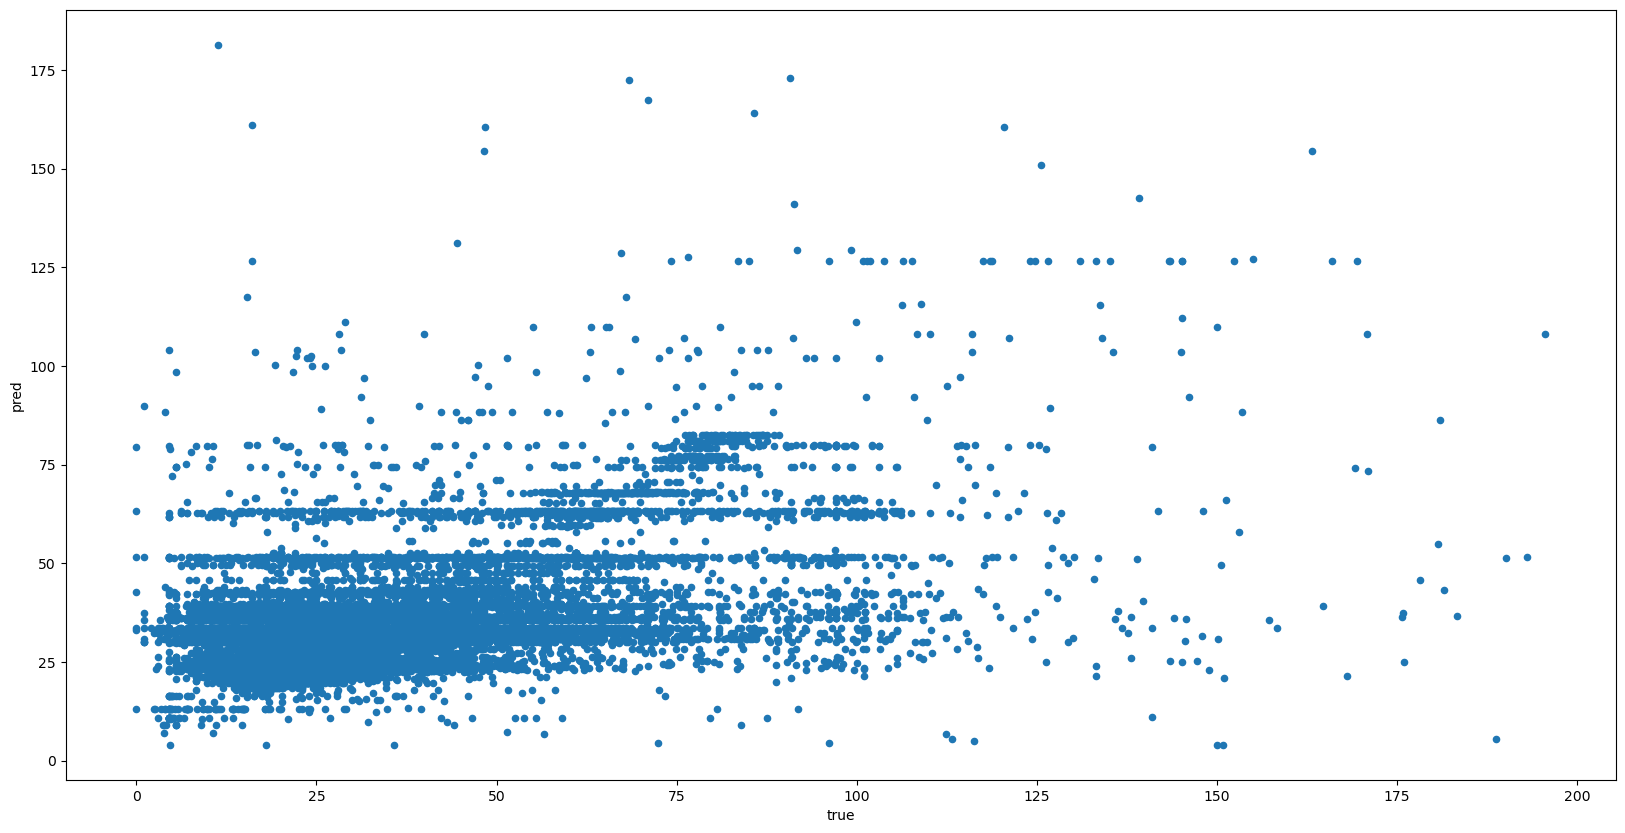

In [84]:
data = {'true': y_test, 'pred': y_pred}
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='pred')

### Overfit
\
The model fits the training data's pattern so much that it loses the ability to generalise.

In [85]:
X_train_overfit = X_train
y_train_overfit = y_train

X_test_overfit = X_test
y_test_overfit = y_test

In [86]:
rmse_scores = {'max_depth': [], 'rmse_train': [], 'rmse_test': []}

for md in [2, 5, 8, 10, 15, 20, 30, 50, 70, 100, 150]:
  print(md)
  decision_tree_overfit = DecisionTreeRegressor(max_depth=md)
  decision_tree_overfit.fit(X_train_overfit, y_train_overfit)

  model_at_hand_overfit = decision_tree_overfit

  y_pred_train = model_at_hand_overfit.predict(X_train_overfit)
  rmse_train = sqrt(mean_squared_error(y_train_overfit, y_pred_train))

  y_pred_test = model_at_hand_overfit.predict(X_test_overfit)
  rmse_test = sqrt(mean_squared_error(y_test_overfit, y_pred_test))

  rmse_scores['max_depth'].append(md)
  rmse_scores['rmse_train'].append(rmse_train)
  rmse_scores['rmse_test'].append(rmse_test)

2
5
8
10
15
20
30
50
70
100
150


In [87]:
pd.DataFrame.from_dict(rmse_scores)

,max_depth,rmse_train,rmse_test
0,2,1.767222e+01,17.493699
1,5,1.638750e+01,16.442347
2,8,1.530245e+01,15.957940
3,10,1.449760e+01,15.984487
4,15,1.190865e+01,17.599321
5,20,8.102567e+00,19.574538
6,30,2.820958e+00,21.015852
7,50,4.547468e-17,21.169518
8,70,4.480095e-17,21.190273
9,100,4.271603e-17,21.167857


Text(0, 0.5, 'root mean squared error')

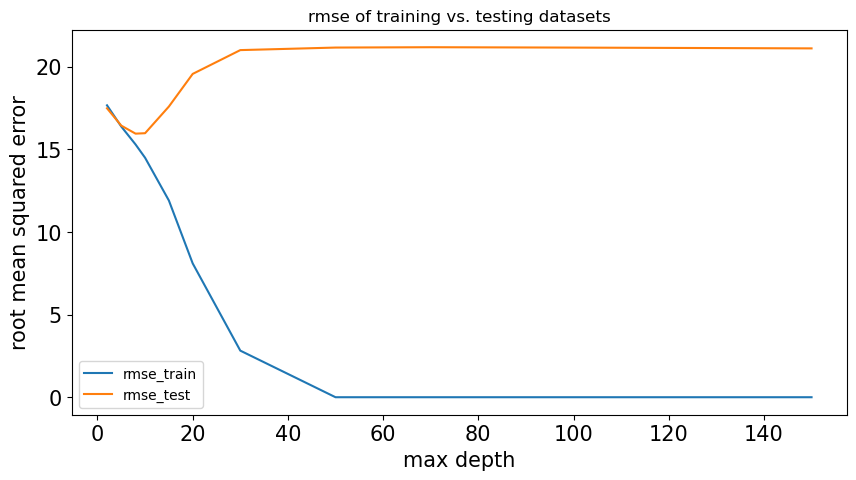

In [88]:
ax = pd.DataFrame.from_dict(rmse_scores).plot(figsize=(10, 5), title='rmse of training vs. testing datasets', fontsize=15, x='max_depth')
ax.set_xlabel('max depth', fontsize=15)
ax.set_ylabel('root mean squared error', fontsize=15)

### Underfit
\
Underfit is when the model cannot capture the data's pattern at all

In [89]:
X_train_underfit = X_train
y_train_underfit = y_train

X_test_underfit = X_test
y_test_underfit = y_test

In [90]:
decision_tree_underfit = DecisionTreeRegressor(max_depth=1)
decision_tree_underfit.fit(X_train_underfit, y_train_underfit)

# Training performance

model_at_hand_underfit = decision_tree_underfit

y_pred_underfit = model_at_hand_underfit.predict(X_train_underfit)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_train_underfit, y_pred_underfit))
print('mean_squared_error', mean_squared_error(y_train_underfit, y_pred_underfit))
print('root_mean_squared_error', sqrt(mean_squared_error(y_train_underfit, y_pred_underfit)))
print('r2', r2_score(y_train_underfit, y_pred_underfit))

mean_absolute_error 11.939859750632932
mean_squared_error 336.5960447550247
root_mean_squared_error 18.346554029436284
r2 0.12412597319417207


In [91]:
# Testing performance

y_pred_underfit = model_at_hand_underfit.predict(X_test_underfit)

model_at_hand_underfit = decision_tree_underfit

y_pred_underfit = model_at_hand_underfit.predict(X_test_underfit)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test_underfit, y_pred_underfit))
print('mean_squared_error', mean_squared_error(y_test_underfit, y_pred_underfit))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test_underfit, y_pred_underfit)))
print('r2', r2_score(y_test_underfit, y_pred_underfit))

mean_absolute_error 11.767035017104217
mean_squared_error 330.7738716459479
root_mean_squared_error 18.187189767689453
r2 0.11729642173935872


## 7.2. Random forest <a id='random_forest'></a>

In [92]:
from sklearn.ensemble import RandomForestRegressor

rando_model = RandomForestRegressor()
rando_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
model_at_hand = rando_model

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))


mean_absolute_error 9.579931374021676
mean_squared_error 255.484025824078
root_mean_squared_error 15.983867674129375
r2 0.31821500089724397


<Axes: xlabel='true', ylabel='pred'>

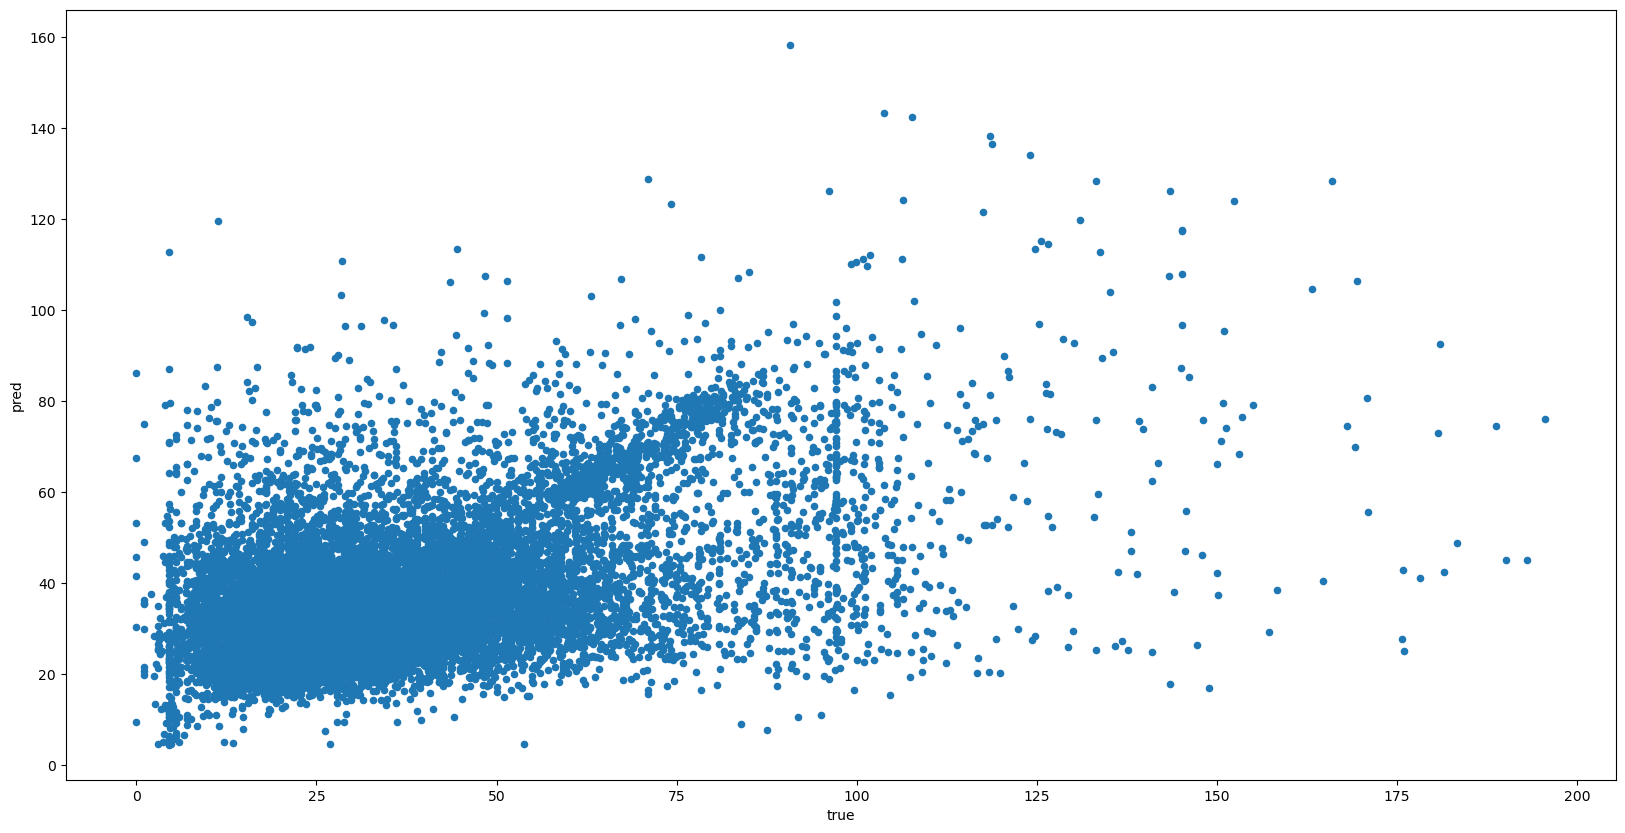

In [94]:
data = {'true': y_test, 'pred': y_pred}
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='pred')

## 7.3. Gradient Boosting <a id='gradient_boosting'></a>

In [95]:
from sklearn.ensemble import GradientBoostingRegressor

gradBooster = GradientBoostingRegressor()
gradBooster.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [96]:
model_at_hand = gradBooster

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred)
print('mean_absolute_error', mae)
print('mean_squared_error', mse)
print('root_mean_squared_error', rmse)
print('r2', r2)

mean_absolute_error 9.836602253629145
mean_squared_error 243.71315417527362
root_mean_squared_error 15.611314940621549
r2 0.34962676408139215


<Axes: xlabel='true', ylabel='pred'>

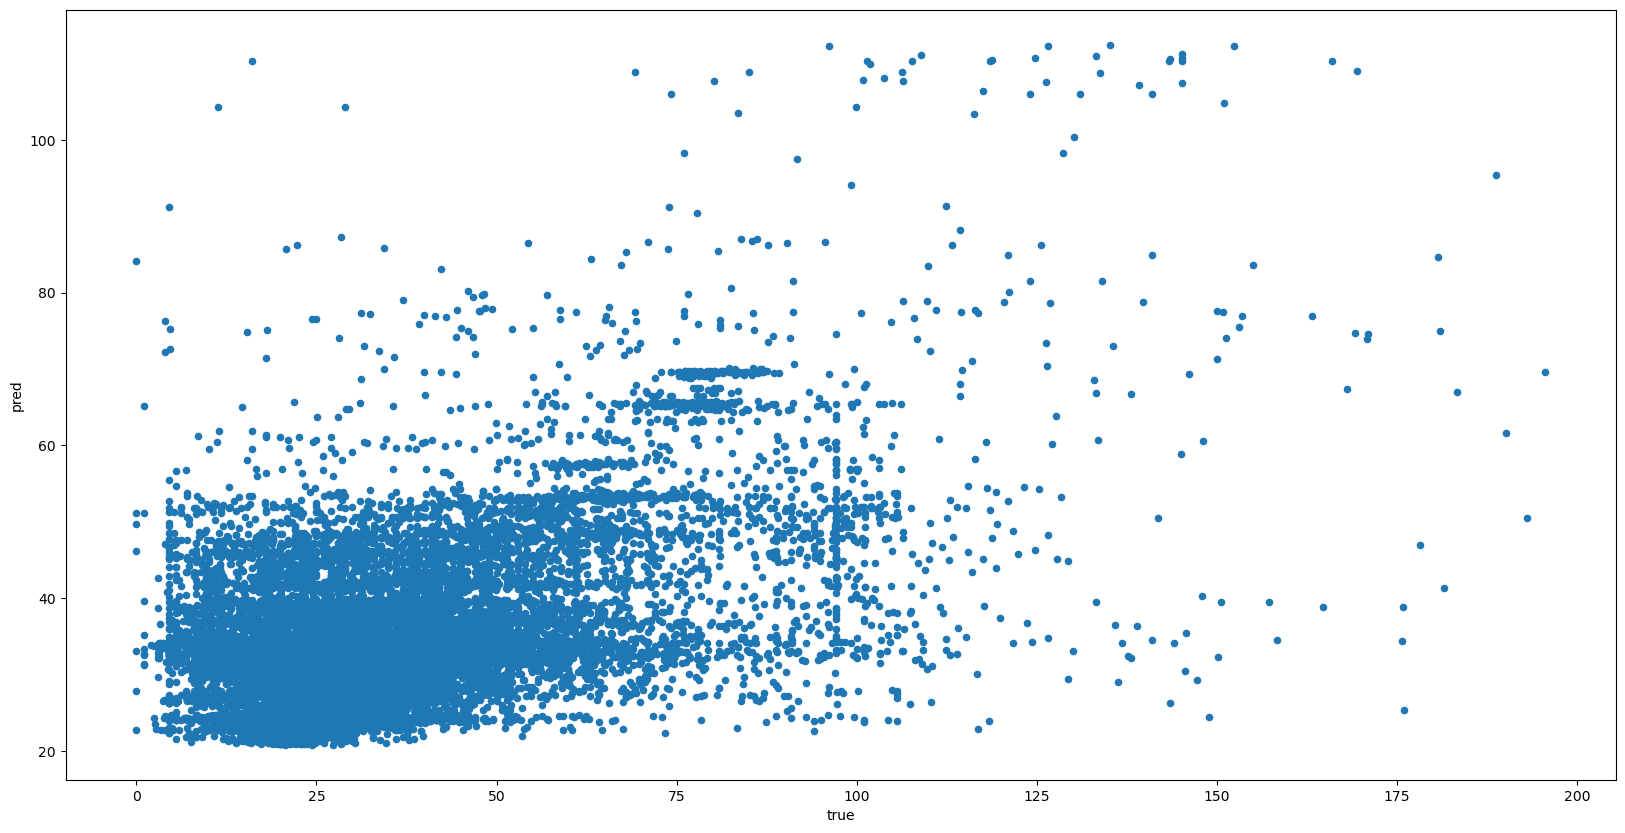

In [97]:
data = {'true': y_test, 'pred': y_pred}
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='pred')

<Axes: >

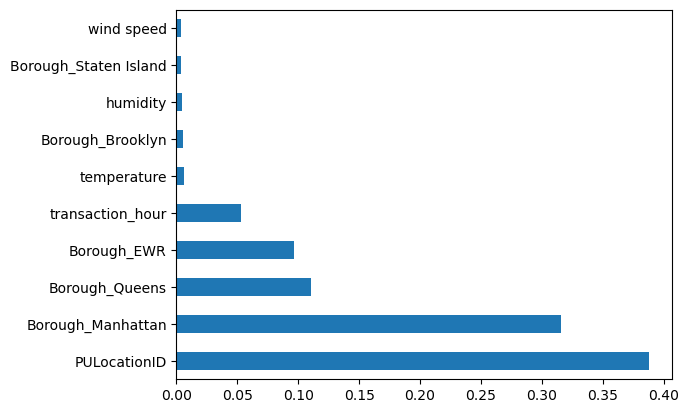

In [98]:
(pd.Series(model_at_hand.feature_importances_, index=X_train.columns)
   .nlargest(10)
   .plot(kind='barh'))

## 7.4. Comparing algorithm performances <a id='comparing_algorithm_performances'></a>

|  Algorithm        | Mean Absolute Error | Mean Squared Error | Root Mean Squared Error | R2 Score |
|:-----------------:|:-------------------:|:------------------:|:-----------------------:|:--------:|
| Benchmark Model   |       6.627         |       167.364      |          12.936         |   0.564  |
| Decision Tree     |       9.568         |       253.888      |          15.933         |   0.322  |
| Random Forest     |       9.581         |       255.316      |          15.978         |   0.318  |
| Gradient Boosting |       9.836         |       243.713      |          15.611         |   0.350  |

# 8. Tuning <a id='tuning'></a>
[Back to top](#table_of_contents)

### 8.1. Find the best hyperparameters <a id='find_the_best_hyperparameters'></a>

In [99]:
# Number of trees in the random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Number of features to consider at every split
max_features = ['auto',  'sqrt']
# Maximum number of levels in tree
max_depth = [10, 20, 50, 100, 150, 200, 300, 500]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10, 20, 40]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4, 10, 20]
# Method of selecting samples for training each tree
bootstrap = [True, False]

In [100]:
import pprint as pp

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

pp.pprint(random_grid)

{'bootstrap': [True, False],
 'max_depth': [10, 20, 50, 100, 150, 200, 300, 500, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4, 10, 20],
 'min_samples_split': [2, 5, 10, 20, 40],
 'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}


In [101]:
# from sklearn.model_selection import RandomizedSearchCV

# rf = RandomForestRegressor()

# rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter= 10, cv = 3, verbose= 2, random_state=42, n_jobs= 2)

# # fit the random search model
# rf_random.fit(X_train, y_train)

# performances = pd.DataFrame.from_dict(rf_random.cv_results_)

In [102]:
# performances

In [103]:

import time
t0 = time.time()

best = RandomForestRegressor(n_estimators= 200, min_samples_split= 40,
                             min_samples_leaf= 4,
                             max_features= 'sqrt',
                             max_depth= 20,
                             bootstrap= False)

best.fit(X_train, y_train)

t1 = time.time() - t0
print('Time elapsed: ', t1, ' seconds')


model_at_hand = best

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('mean_absolute_error', mae)
print('mean_squared_error', mse)
print('root_mean_squared_error', rmse)
print('r2', r2)

Time elapsed:  11.461463212966919  seconds
mean_absolute_error 10.04801448411864
mean_squared_error 253.51412987595194
root_mean_squared_error 15.922127052499988
r2 0.3234718677518098


In [104]:
import time
t0 = time.time()

best = RandomForestRegressor(n_estimators= 1800, min_samples_split= 2,
                             min_samples_leaf= 4,
                             max_features= 'sqrt',
                             max_depth= 300,
                             bootstrap= True)

best.fit(X_train, y_train)

t1 = time.time() - t0
print('Time elapsed: ', t1, ' seconds')


model_at_hand = best

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('mean_absolute_error', mae)
print('mean_squared_error', mse)
print('root_mean_squared_error', rmse)
print('r2', r2)

Time elapsed:  77.47827816009521  seconds
mean_absolute_error 10.18484408297352
mean_squared_error 258.9353707239735
root_mean_squared_error 16.091468880247493
r2 0.30900473746927193


In [105]:
from sklearn.ensemble import RandomForestRegressor

import time

t0 = time.time()

second_best = RandomForestRegressor(n_estimators= 200, min_samples_split= 10,
                                    min_samples_leaf= 2,
                                    max_features= 'sqrt',
                                    max_depth= 150,
                                    bootstrap= True)

second_best.fit(X_train, y_train)

t1 = time.time() - t0
print("Time elapsed: ", t1, " seconds")

model_at_hand = second_best

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred)
print('mean_absolute_error', mae)
print('mean_squared_error', mse)
print('root_mean_squared_error', rmse)
print('r2', r2)

Time elapsed:  8.869913578033447  seconds
mean_absolute_error 10.238461963193506
mean_squared_error 261.6682703006681
root_mean_squared_error 16.176163645953515
r2 0.3017117181525666


<Axes: xlabel='true', ylabel='pred'>

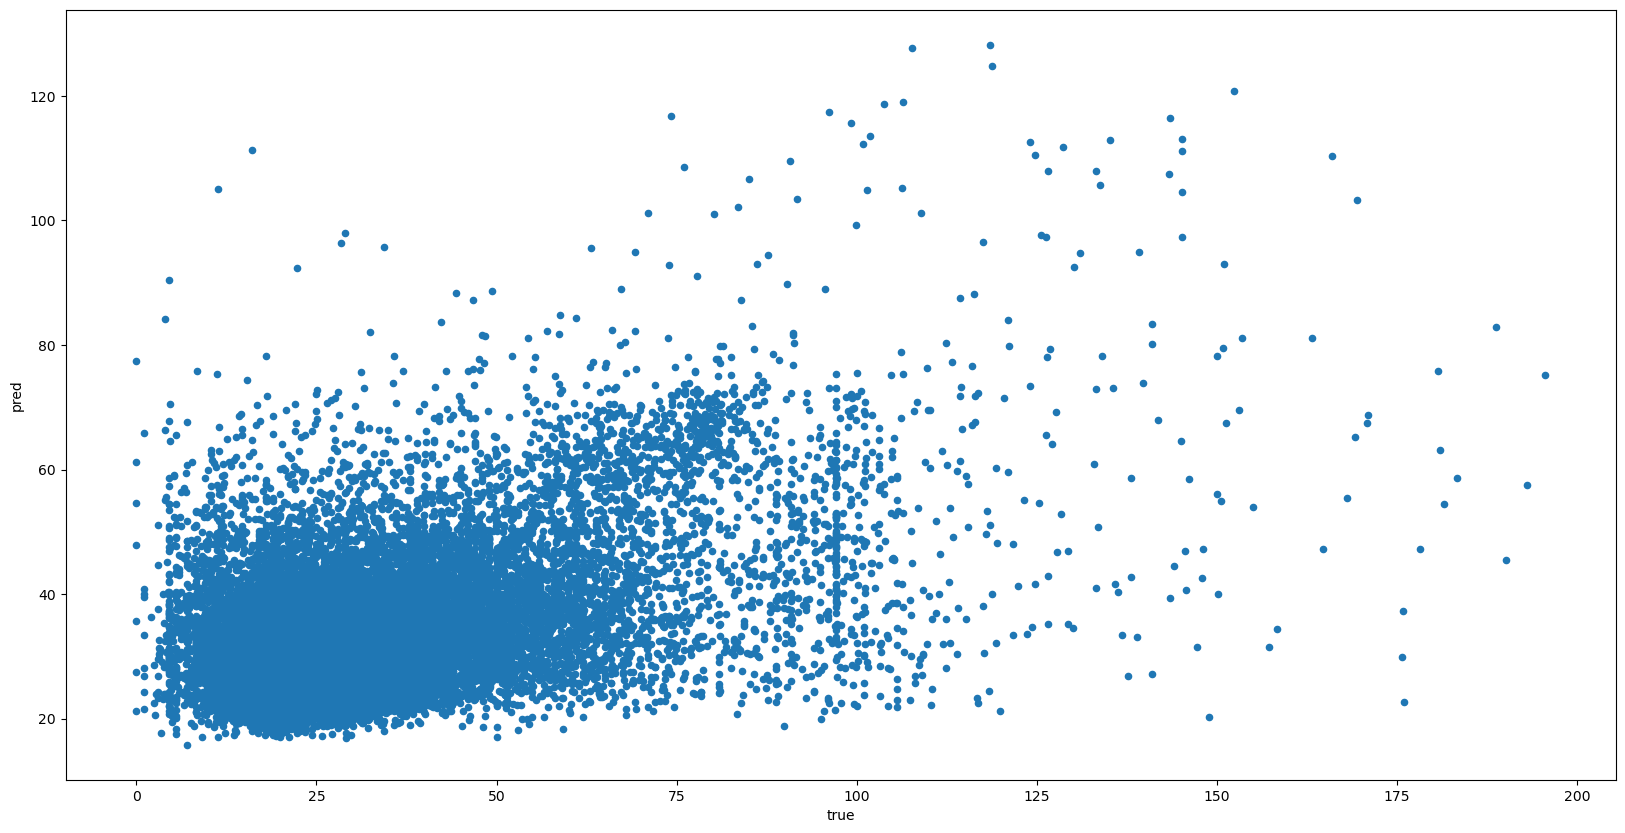

In [106]:
data = {'true': y_test, 'pred': y_pred}
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='pred')

## Bonus: Classification task <a id='classification_task'></a>
[Back to top](#table_of_contents)

<Axes: >

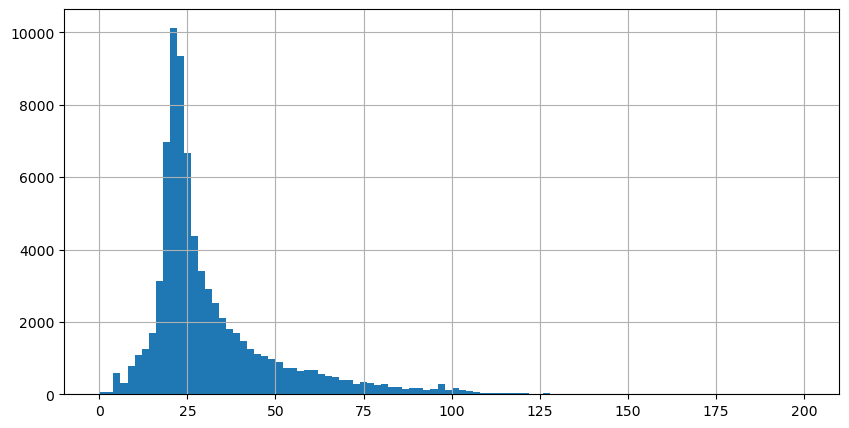

In [107]:
nyc_taxi_with_weather['total_amount'].hist(bins=100, figsize=(10, 5))

In [127]:
nyc_class = nyc_taxi_with_weather.copy()
nyc_class['earning_class'] = nyc_taxi_with_weather['total_amount'].apply(lambda x: 'low' if x <= 24 else 'high')
nyc_class['earning_class_binary'] = nyc_class['earning_class'].apply(lambda x: 0 if x == 'low' else 1)
nyc_class.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough,temperature,humidity,wind speed,cloud cover,amount of precipitation,earning_class,earning_class_binary
0,4,2024-01-01,1,1,0,2.858333,29.452083,24,0,False,True,Manhattan,8.3,97.0,0.0,1.0,29.0,high,1
1,7,2024-01-01,1,1,0,6.265000,28.910000,4,0,False,True,Queens,8.3,97.0,0.0,1.0,29.0,high,1
2,9,2024-01-01,1,1,0,19.900000,60.420000,1,0,False,True,Queens,8.3,97.0,0.0,1.0,29.0,high,1
3,10,2024-01-01,1,1,0,4.810000,40.748333,6,0,False,True,Queens,8.3,97.0,0.0,1.0,29.0,high,1
4,12,2024-01-01,1,1,0,6.005000,34.102500,4,0,False,True,Manhattan,8.3,97.0,0.0,1.0,29.0,high,1


In [128]:
nyc_class['earning_class'].value_counts()

earning_class
high    41731
low     35702
Name: count, dtype: int64

In [129]:
categorical_features = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour', 'transaction_week_day', 'weekend', 'is_holiday', 'Borough']
input_features = categorical_features + ['temperature', 'humidity', 'wind speed', 'cloud cover', 'amount of precipitation']
target_feature = 'earning_class_binary'

In [130]:
from sklearn.model_selection import train_test_split

X_c = nyc_class[input_features]
y_c = nyc_class[target_feature]

# one-hot encoding
X_c = pd.get_dummies(X_c)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.33, random_state=42)

In [131]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)

In [132]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test_c, y_pred_c))

print('accuracy', accuracy_score(y_test_c, y_pred_c))
print('precision', precision_score(y_test_c, y_pred_c))
print('recall', recall_score(y_test_c, y_pred_c))

[[7021 4669]
 [4606 9257]]
accuracy 0.6370289202833327
precision 0.6647278471923022
recall 0.66774868354613


<Axes: >

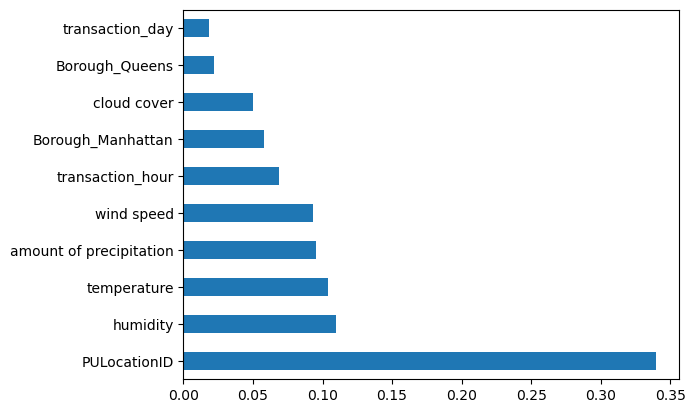

In [133]:
(pd.Series(clf.feature_importances_, index=X_train_c.columns)
   .nlargest(10)
   .plot(kind='barh'))